# Marketing Campaigns

### <u>Ninad Chavan</u>

## Problem Scenario

Marketing mix stands as a widely utilized concept in the execution of marketing strategies. It encompasses various facets within a comprehensive marketing plan, with a central focus on the four Ps of marketing: product, price, place, and promotion.

## Problem Objective

As a data scientist, you must conduct exploratory data analysis and hypothesis testing to enhance your comprehension of the diverse factors influencing customer acquisition.

## Data Description

The dataset aligns with the Four Ps of Marketing, categorizing variables to analyze consumer behavior. Product-related variables track spending across categories, while Price factors like income and deal-based purchases indicate affordability. Place covers shopping channels and web visits, reflecting purchase preferences. Promotion measures campaign engagement, complaints, and recency. Additionally, demographics support segmentation for personalized marketing. This structured approach helps businesses optimize products, pricing, distribution, and promotions for better customer engagement and market performance.

## 1. Import the Data and Examine Variables

After importing the data, examine variables such as `Dt_Customer` and `Income` to verify their accurate importation.

In [489]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize
import numpy as np
import seaborn as sns
from scipy import stats

df = pd.read_csv("datasets/marketing_data.csv")

# Examine the structure of the data first
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   2240 non-null   int64
 1   Year_Birth           2240 non-null   int64
 2   Education            2240 non-null   str  
 3   Marital_Status       2240 non-null   str  
 4    Income              2216 non-null   str  
 5   Kidhome              2240 non-null   int64
 6   Teenhome             2240 non-null   int64
 7   Dt_Customer          2240 non-null   str  
 8   Recency              2240 non-null   int64
 9   MntWines             2240 non-null   int64
 10  MntFruits            2240 non-null   int64
 11  MntMeatProducts      2240 non-null   int64
 12  MntFishProducts      2240 non-null   int64
 13  MntSweetProducts     2240 non-null   int64
 14  MntGoldProds         2240 non-null   int64
 15  NumDealsPurchases    2240 non-null   int64
 16  NumWebPurchases      2240 non-null 

In [490]:
# Clean up column names ("Income" was written " Income ")
df.columns = df.columns.str.strip()
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country'],
      dtype='str')

In [491]:
# Examine the variable "Dt_Customer"
df["Dt_Customer"].head()

0    6/16/14
1    6/15/14
2    5/13/14
3    5/11/14
4     4/8/14
Name: Dt_Customer, dtype: str

In [492]:
# Convert "Dt_Customer" to datetime
df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    format="%m/%d/%y"
)
df["Dt_Customer"].head()

0   2014-06-16
1   2014-06-15
2   2014-05-13
3   2014-05-11
4   2014-04-08
Name: Dt_Customer, dtype: datetime64[us]

In [493]:
# Examine the variable "Income"
df["Income"].head()

0    $84,835.00 
1    $57,091.00 
2    $67,267.00 
3    $32,474.00 
4    $21,474.00 
Name: Income, dtype: str

In [494]:
# Clean up the string income values
df["Income_Cleaned"] = (
    df["Income"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

# Convert to float
# Remaining unusual values will be converted to NaN via coerce
df["Income_Cleaned"] = pd.to_numeric(
    df["Income_Cleaned"],
    errors="coerce"
)

df["Income_Cleaned"].head()

0    84835.0
1    57091.0
2    67267.0
3    32474.0
4    21474.0
Name: Income_Cleaned, dtype: float64

## 2. Missing Value Imputation and Data Cleaning

There are missing income values for some customers. Conduct missing value imputation, considering that customers with similar education and marital status tend to have comparable yearly incomes, on average.

It may be necessary to cleanse the data before proceeding. Specifically, scrutinize the categories of education and marital status for data cleaning.

In [495]:
# Cleanse the data

# Check for missing values --> False means that all are present
print(df["Education"].isna().any())
print(df["Marital_Status"].isna().any())
print()

# Check for unique values and counts --> All look fine
print(df["Education"].unique())
print(df["Education"].value_counts())
print()

# Marital_Status contains a few unusual values --> Alone, YOLO, Absurd
print(df["Marital_Status"].unique())
print(df["Marital_Status"].value_counts())
print()

# Given that "Together" has 580 values, it can remain a valid data point
# Cannot be certain whether Alone is Single, Widow, or Divorced

print(len(df))

# 7 / 2240 records is 0.31% of the data
# Simplest option is to drop these unusual rows
df = df[~df["Marital_Status"].isin(["Alone", "YOLO", "Absurd"])]
print(len(df))

# Impute in next cell

False
False

<StringArray>
['Graduation', 'PhD', '2n Cycle', 'Master', 'Basic']
Length: 5, dtype: str
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

<StringArray>
['Divorced', 'Single', 'Married', 'Together', 'Widow', 'YOLO', 'Alone',
 'Absurd']
Length: 8, dtype: str
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
YOLO          2
Absurd        2
Name: count, dtype: int64

2240
2233


In [496]:
# Customers with similar education and marital status tend to have
# comparable yearly incomes, on average.

# We have NaN values in the parsed income (it prints True)
print(df["Income_Cleaned"].isna().any())

# Use transform() as it calculates and stores for each row
df["Income_Cleaned"] = df["Income_Cleaned"].fillna(
    df.groupby([
        "Education",
        "Marital_Status"
    ])["Income_Cleaned"].transform("mean")
)

# Verify that all have been filled (it prints False)
print(df["Income_Cleaned"].isna().any())


True
False


## 3. Create Variables

Create variables to represent:
- The total number of children
- Age
- Total spending

In [497]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

# Dataset looks to have information from 2012-2014
# Will use the year from the max of the "Dt_Customer" column
# Using 2026 may be too far in advance for calculating age
df["Age"] = df["Dt_Customer"].max().year - df["Year_Birth"]

# Written explicitly for readability
spending_columns = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

# Add across each row, rather than down column
df["Total_Spending"] = df[spending_columns].sum(axis=1)

df[["Age", "Total_Children", "Total_Spending"]].head()

,Age,Total_Children,Total_Spending
0,44,0,1190
1,53,0,577
2,56,1,251
3,47,2,11
4,25,1,91


### 3a. Total Purchases

Derive the total purchases from the number of transactions across the three channels.

In [498]:
# NumDealsPurchases is not a separate channel
# A purchase could be both through a store and as a deal
purchase_columns = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

df["Total_Purchases"] = df[purchase_columns].sum(axis=1)

df[[
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "Total_Purchases",
]]

,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Total_Purchases
0,4,4,6,14
1,7,3,7,17
2,3,2,5,10
3,1,0,2,3
4,3,1,2,6
...,...,...,...,...
2235,5,2,11,18
2236,1,0,3,4
2237,6,1,5,12
2238,5,4,10,19


## 4. Distributions and Outliers

Generate box plots and histograms to gain insights into the distributions and identify outliers. Implement outlier treatment as needed.

In [499]:
def show_plots(in_df: pd.DataFrame, in_var: str):
    """Create a box plot and histogram for the given column."""
    # Box plot
    in_df.boxplot(column=in_var)
    plt.title(f"{in_var} Box Plot")
    plt.show()
    
    # Histogram
    in_df[in_var].hist()
    plt.title(f"{in_var} Distribution")
    plt.xlabel(in_var)
    plt.ylabel("Frequency")
    plt.show()

In [500]:
def print_outliers(in_df: pd.DataFrame, in_var: str):
    """Print the outliers for the given column."""
    Q1 = in_df[in_var].quantile(0.25)
    Q3 = in_df[in_var].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = (
        (in_df[in_var] < lower) |
        (in_df[in_var] > upper)
    )

    # Print the outliers in descending order
    print(in_df[outliers][in_var].sort_values(ascending=False), "\n")

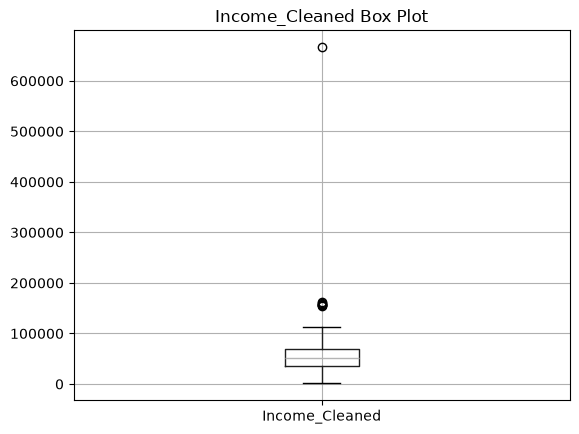

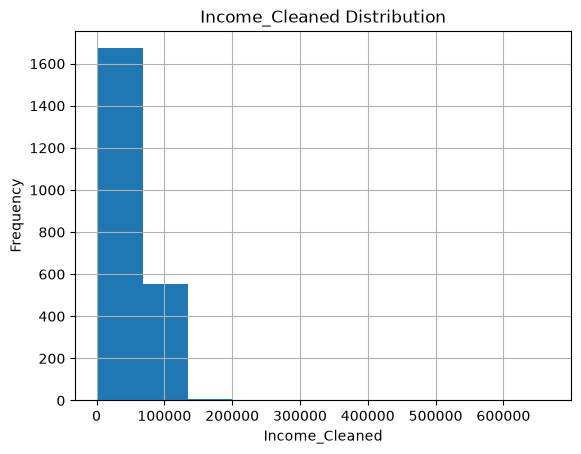

527     666666.0
731     162397.0
497     160803.0
853     157733.0
2204    157243.0
325     157146.0
1925    156924.0
1826    153924.0
Name: Income_Cleaned, dtype: float64 



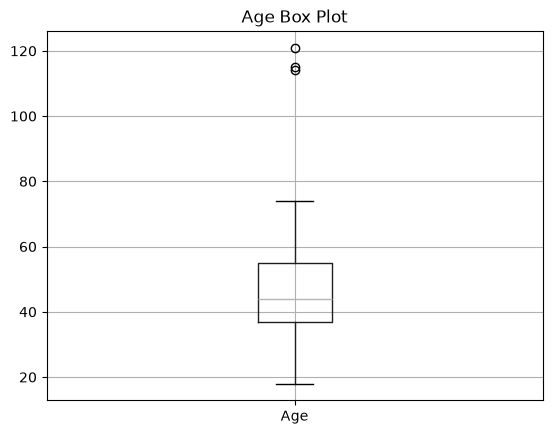

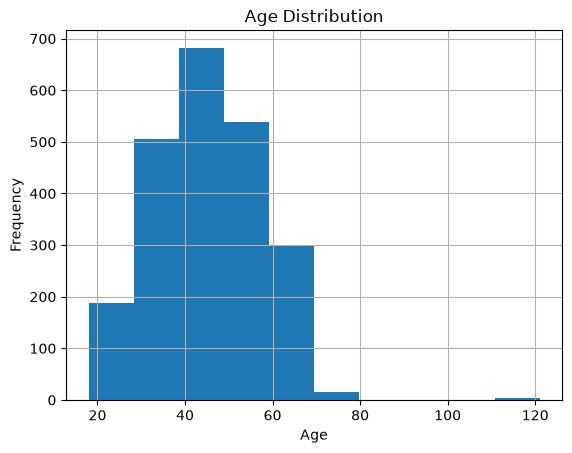

513     121
827     115
2233    114
Name: Age, dtype: int64 



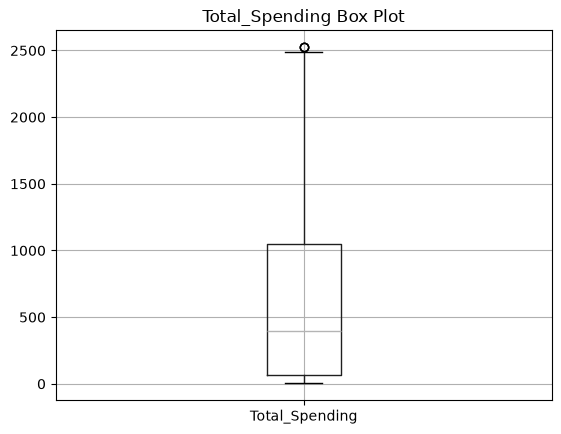

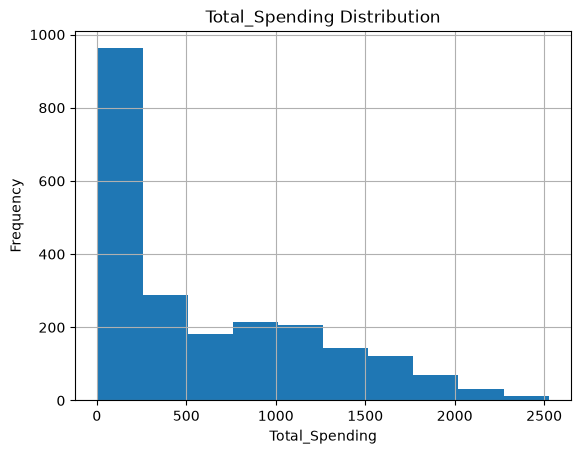

671     2525
672     2525
1404    2524
Name: Total_Spending, dtype: int64 



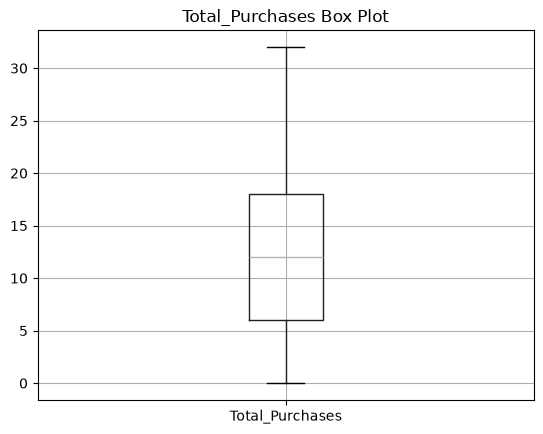

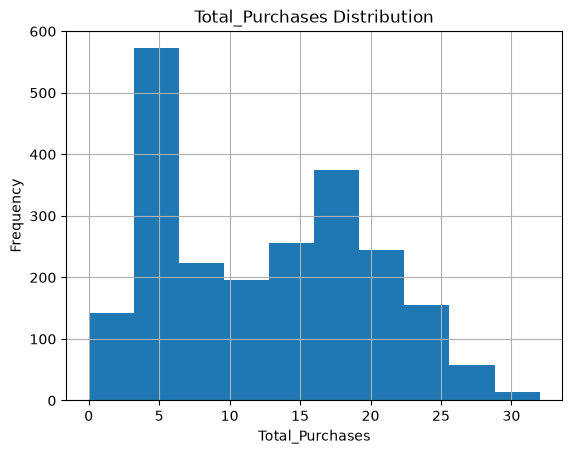

Series([], Name: Total_Purchases, dtype: int64) 



In [501]:
variables = [
    "Income_Cleaned",
    "Age",
    "Total_Spending",
    "Total_Purchases"
]

for variable in variables:
    show_plots(df, variable)
    print_outliers(df, variable)

# Found outliers for: Income_Cleaned, Age, Total_Spending

In [502]:
# A large outlier of $666666.0 is found in income
print_outliers(df, "Income_Cleaned")

# The rest appear to be reasonable
# As it is only one data point, it will be dropped for simplicity
df = df.drop(527)

print("Cleared:")
print_outliers(df, "Income_Cleaned")

527     666666.0
731     162397.0
497     160803.0
853     157733.0
2204    157243.0
325     157146.0
1925    156924.0
1826    153924.0
Name: Income_Cleaned, dtype: float64 

Cleared:
731     162397.0
497     160803.0
853     157733.0
2204    157243.0
325     157146.0
1925    156924.0
1826    153924.0
Name: Income_Cleaned, dtype: float64 



In [503]:
# Age has three outliers, far above the next max of 74
print_outliers(df, "Age")

df["Age"].sort_values(ascending=False).head()

# These also shall be dropped for simplicty
df = df.drop([513, 827, 2233])
print_outliers(df, "Age")

513     121
827     115
2233    114
Name: Age, dtype: int64 

Series([], Name: Age, dtype: int64) 



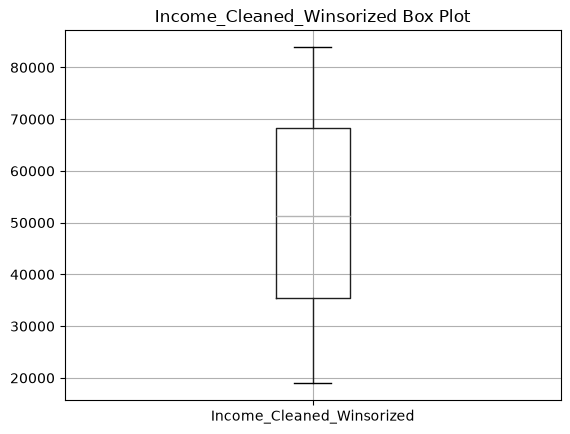

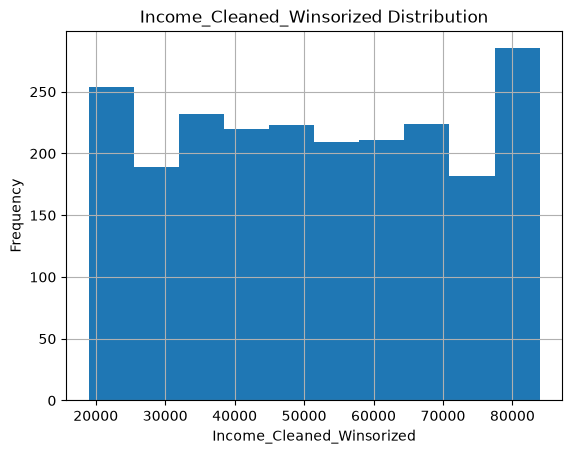

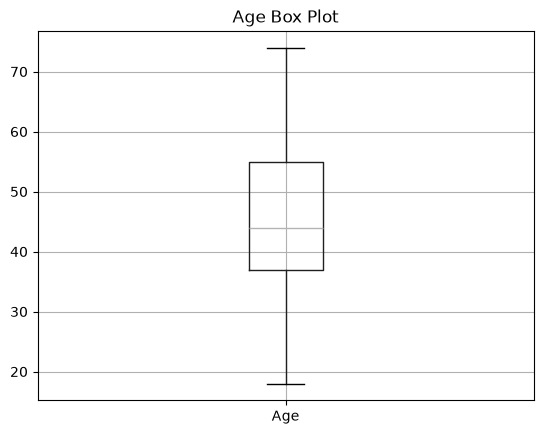

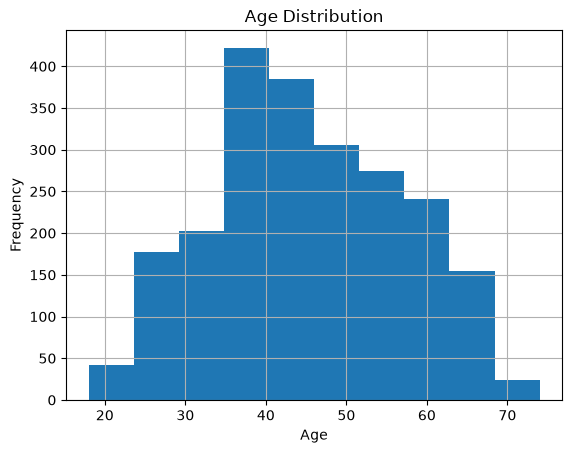

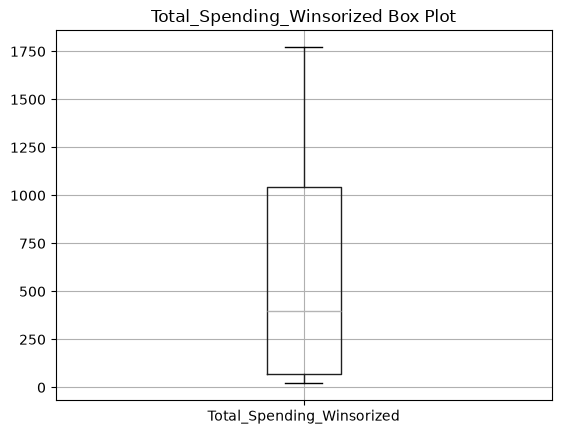

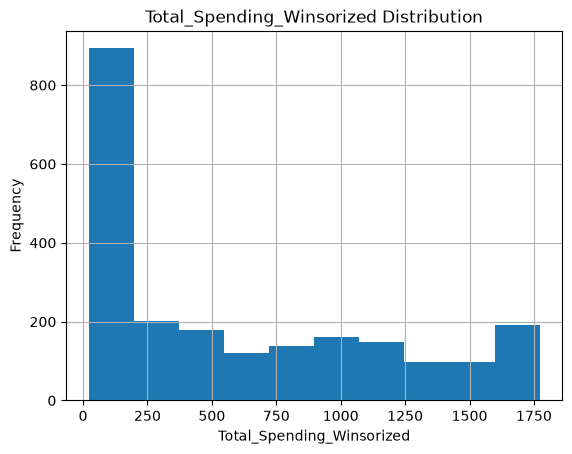

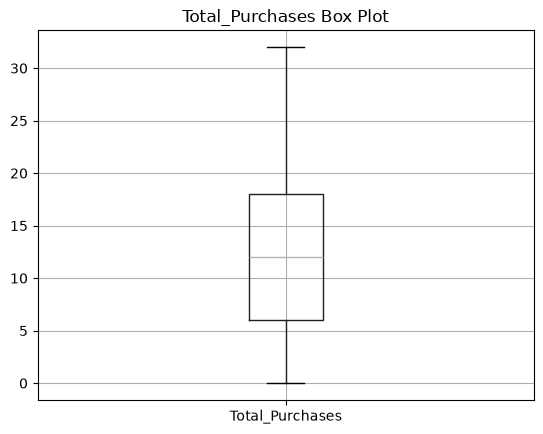

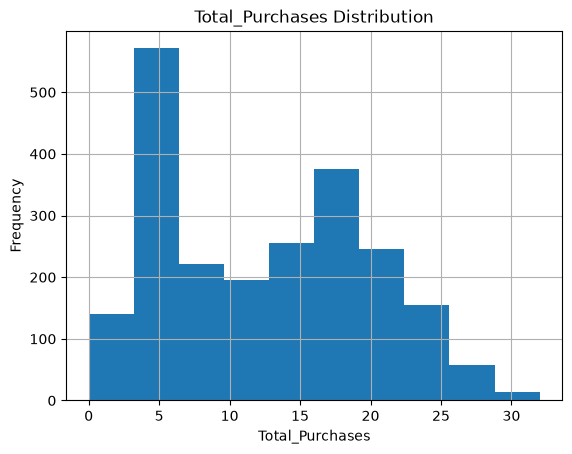

In [504]:
# Address the other income values, and spending via winsorization
to_winsorize = ["Income_Cleaned", "Total_Spending"]

# Winsorize those columns
for col_name in to_winsorize:
    # Convert column to numpy array
    col_vals = df[col_name].to_numpy(dtype=np.float64)

    winsorized_col_name = f"{col_name}_Winsorized"

    df[winsorized_col_name] = winsorize(
        col_vals,
        limits=[0.05, 0.05]  # Cap the bottom 5% and top 5% of prices
    )

new_variables = [
    "Income_Cleaned_Winsorized",
    "Age",
    "Total_Spending_Winsorized",
    "Total_Purchases"
]
for var in new_variables:
    show_plots(df, var)

## 5. Categorical Variable Encoding

Apply ordinal and one-hot encoding based on the various types of categorical variables.

In [505]:
# Ordinal (label) encoding for education levels
rating_order = {
    "Basic": 0,
    "2n Cycle": 1,
    "Graduation": 2,
    "Master": 3,
    "PhD": 4,
}

df["Education_Encoded"] = df["Education"].map(rating_order)
print(df["Education_Encoded"])

0       2
1       2
2       2
3       2
4       2
       ..
2235    4
2236    1
2237    2
2238    2
2239    4
Name: Education_Encoded, Length: 2229, dtype: int64


In [506]:
# One-hot encoding
df_hot_encoded = pd.get_dummies(
    df[["Marital_Status", "Country"]],
    columns=["Marital_Status", "Country"],
)
print(df_hot_encoded.head())

# Other variables are numerical and do not need ordinal or one-hot encoding

   Marital_Status_Divorced  Marital_Status_Married  Marital_Status_Single  \
0                     True                   False                  False   
1                    False                   False                   True   
2                    False                    True                  False   
3                    False                   False                  False   
4                    False                   False                   True   

   Marital_Status_Together  Marital_Status_Widow  Country_AUS  Country_CA  \
0                    False                 False        False       False   
1                    False                 False        False        True   
2                    False                 False        False       False   
3                     True                 False         True       False   
4                    False                 False        False       False   

   Country_GER  Country_IND  Country_ME  Country_SA  Country_SP  Country_U

## 6. Correlation Heatmap

Generate a heatmap to illustrate the correlation between different pairs of variables.

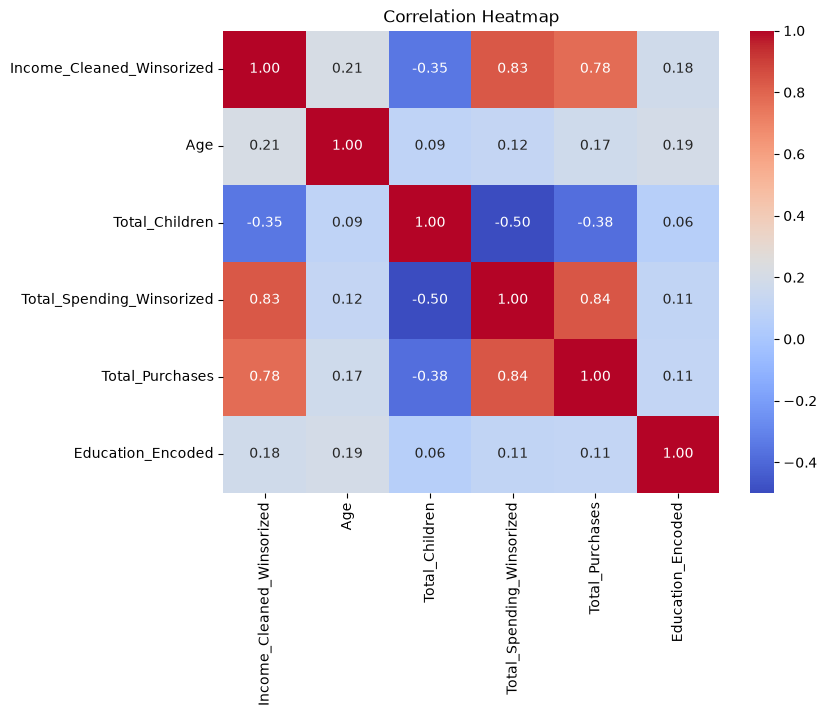

In [507]:
# Keep heatmap compact
# Use winsorized data to minimize extreme observations
correlation_columns = [
    "Income_Cleaned_Winsorized",
    "Age",
    "Total_Children",
    "Total_Spending_Winsorized",
    "Total_Purchases",
    "Education_Encoded"
]

correlation_matrix = df[correlation_columns].corr()

# Adjust length and width of the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

## 7. Hypothesis Testing

Test the following hypotheses:

### 7a.
Older individuals may not possess the same level of technological proficiency and may, therefore, lean toward traditional in-store shopping preferences.

- $μ_1$ = mean number of in-store purchases for older adults (65 and older)
- $μ_2$ = mean number of in-store purchases for younger adults (<65)

**$H_0$: Older adults do not buy more in-store than younger adults.**
- $μ_1 <= μ_2$

**$H_a$:  Older adults do buy more in-store than younger adults.**
- $μ_1 > μ_2$

In [ ]:
# Use the age of 65 and above as senior citizens
older_purchases = df[df["Age"] >= 65]["NumStorePurchases"]
younger_purchases = df[df["Age"] < 65]["NumStorePurchases"]

# equal_var means to assume different variances (Welch's t-test)
t_stat, p_value = stats.ttest_ind(
    older_purchases,
    younger_purchases,
    equal_var=False,
    alternative="greater",  # First group mean > Second group mean
)

print("Mean Older Adults:", older_purchases.mean())
print("Mean Younger Adults:", younger_purchases.mean())
print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to reject H0")

# We reject the null hypothesis. There is sufficient evidence to conclude that 
# older adults buy more in-store than younger adults.

Mean Older Adults: 7.177570093457944
Mean Younger Adults: 5.727615457115928
t-statistic: 4.188360189618312
p-value: 2.7623893659875192e-05
Reject H0


### 7b.
Customers with children likely experience time constraints, making online shopping a more convenient option.

- $μ_1$ = mean number of web purchases for customers with children
- $μ_2$ = mean number of web purchases for customers without children

**$H_0$: Customers with children do not buy more online than those without.**
- $μ_1 <= μ_2$

**$H_a$: Customers with children do buy more online than those without.**
- $μ_1 > μ_2$

In [ ]:
with_children = df[df["Total_Children"] > 0]["NumWebPurchases"]
without_children = df[df["Total_Children"] <= 0]["NumWebPurchases"]

# equal_var means to assume different variances (Welch's t-test)
t_stat, p_value = stats.ttest_ind(
    with_children,
    without_children,
    equal_var=False,
    alternative="greater",  # First group mean > Second group mean
)

print("Mean Web Purchases with Children:", with_children.mean())
print("Mean Web Purchases without Children:", without_children.mean())
print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to reject H0")

# We fail to reject the null hypothesis. There is insufficient evidence to
# conclude that customers with children buy more online than those without.

Mean Web Purchases with Children: 3.959849435382685
Mean Web Purchases without Children: 4.396850393700787
t-statistic: -3.5748108432903085
p-value: 0.999818523815857
Fail to reject H0


### 7c.
Sales at physical stores may face the risk of cannibalization by alternative distribution channels.

- $μ_1$ = mean number of in-store purchases
- $μ_2$ = mean number of alternative-channel purchases (web + catalog)

**$H_0$: In-store purchases are not lower than the same customers' purchases through alternative distribution channels.**
- $μ_1 >= μ_2$

**$H_a$: In-store purchases are lower than the same customers' purchases through alternative distribution channels.**
- $μ_1 < μ_2$

In [510]:
sales_physical = df["NumStorePurchases"]
sales_alt = df["NumCatalogPurchases"] + df["NumWebPurchases"]

# Paired t-test because same customer is being compared
t_stat, p_value = stats.ttest_rel(
    sales_physical,
    sales_alt,
    alternative="less",  # First group mean < Second group mean
)

print("Mean Store Purchases:", sales_physical.mean())
print("Mean Alternative Distribution Channels:", sales_alt.mean())
print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to reject H0")

# We reject the null hypothesis. There is sufficient evidence to conclude that
# in-store purchases are lower than the same customers' purchases through
# alternative distribution channels.
#
# This suggests that alternative distribution channels may be associated with
# lower purchase activity at physical stores.

Mean Store Purchases: 5.797218483624944
Mean Alternative Distribution Channels: 6.7474203678779725
t-statistic: -11.962181609109937
p-value: 2.619484786953239e-32
Reject H0


### 7d.
Does the United States significantly outperform the rest of the world in total purchase volumes?

- $μ_1$ = mean total purchase volume per customer in the United States
- $μ_2$ = mean total purchase volume per customer in countries outside the United States

**$H_0$: The United States does not outperform the world in total purchase volume.**
- $μ_1 <= μ_2$

**$H_a$: The United States does outperform the world in total purchase volume.**
- $μ_1 > μ_2$

In [ ]:
us_purchases = df[df["Country"] == "US"]["Total_Purchases"]
non_us_purchases = df[df["Country"] != "US"]["Total_Purchases"]

# equal_var means to assume different variances (Welch's t-test)
t_stat, p_value = stats.ttest_ind(
    us_purchases,
    non_us_purchases,
    equal_var=False,
    alternative="greater",  # First group mean > Second group mean
)

print("Mean US Purchase Volume:", us_purchases.mean())
print("Mean Non-US Purchase Volume:", non_us_purchases.mean())
print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to reject H0")

# We fail to reject the null hypothesis. There is insufficient evidence to 
# conclude that the US outperforms the rest of the world in purchase volume.

Mean US Purchase Volume: 13.513761467889909
Mean Non-US Purchase Volume: 12.494811320754717
t-statistic: 1.45691239771896
p-value: 0.07387944456621705
Fail to reject H0


## 8. Visualization and Analysis

Use appropriate visualization to help analyze the following:

### 8a.
Identify the top-performing products and those with the lowest revenue.

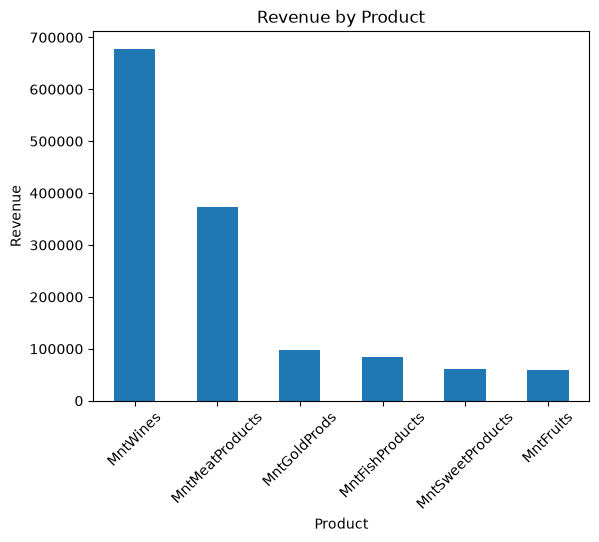

In [512]:
# Now add down the product columns
product_revenue = df[spending_columns].sum()

product_revenue = product_revenue.sort_values(ascending=False)
product_revenue.plot(kind="bar")

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

# Highest performing - Wines and Meats
# Lowest performing - Fruits

### 8b.
Examine if there is a correlation between customers' age and the acceptance rate of the last campaign.

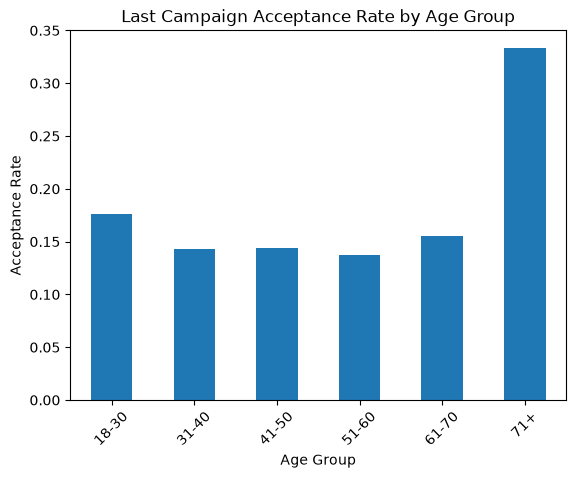

In [513]:
age_groups = pd.cut(
    df["Age"],
    bins=[18, 30, 40, 50, 60, 70, 100],
    labels=["18-30", "31-40", "41-50", "51-60", "61-70", "71+"]
)

acceptance_rate = df.groupby(
    age_groups,
    observed=True  # Ignore bins that are empty
)["Response"].mean()

acceptance_rate.plot(kind="bar")

plt.title("Last Campaign Acceptance Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Acceptance Rate")
plt.xticks(rotation=45)
plt.show()

# From the graph, there does not appear to be a clear correlation visible 
# between customer age and acceptance of the last campaign. However, adults
# 71+ had the highest mean campaign acceptance rate.

### 8c.
Determine the country with the highest number of customers who accepted the last campaign.

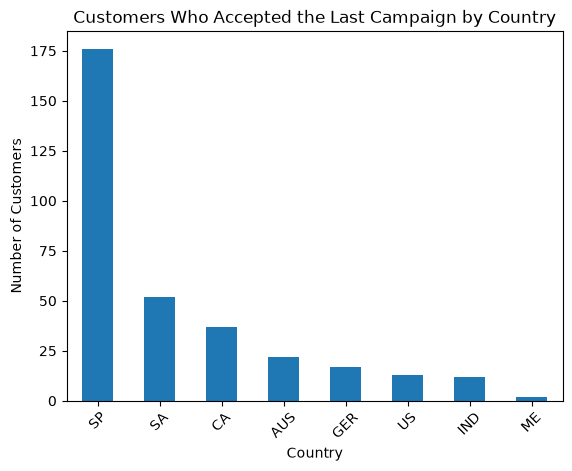

In [514]:
# Get the count of customers saying True for Response per country
# Then sort the counts
accepted_by_country = (
    df[df["Response"] == 1]
    .groupby("Country")
    .size()
    .sort_values(ascending=False)
)

accepted_by_country.plot(kind="bar")

plt.title("Customers Who Accepted the Last Campaign by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

# The country with the highest number of customers who accepted the last
# campaign is SP.

### 8d.
Investigate if there is a discernible pattern in the number of children at home and the total expenditure.

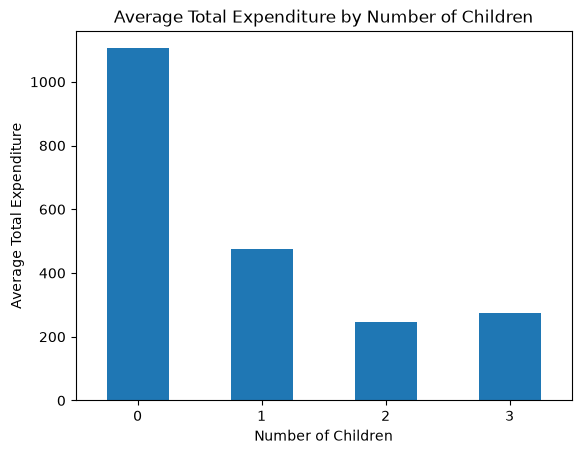

In [ ]:
# Calculate the mean spending per group with children
spending_by_children = (
    df.groupby("Total_Children")["Total_Spending"]
    .mean()
)

spending_by_children.plot(kind="bar")

plt.title("Average Total Expenditure by Number of Children")
plt.xlabel("Number of Children")
plt.ylabel("Average Total Expenditure")
plt.xticks(rotation=0)
plt.show()

# Total expenditure is highest amongst customers without children.
# It is least amongst customers with exactly 2 children.
# It generally reduces as the number of children increases, but slightly 
# increases with 3 children.

### 8e.
Analyze the educational background of customers who lodged complaints in the last two years.

Education
Graduation    1124
PhD            482
Master         368
2n Cycle       201
Basic           54
Name: count, dtype: int64


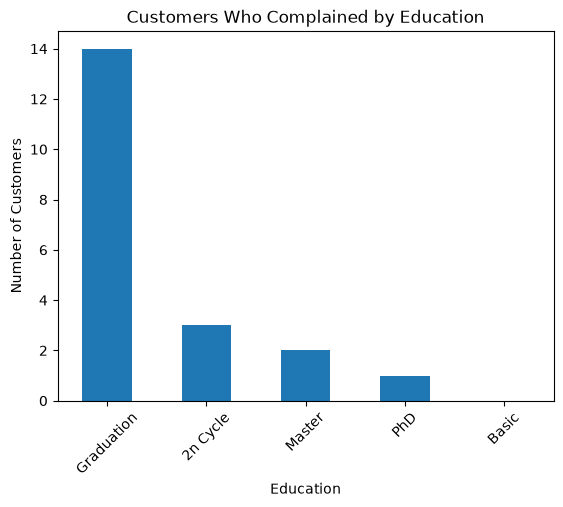

In [518]:
# Check size of Graduation pool
print(df["Education"].value_counts())

# Group customers by education and go to the Complain column
# The values are 0s and 1s, get their sum
# (This is so that Basic appears on the graph, it has a sum of 0)
# Sort in a descending manner
complaints_by_education = (
    df.groupby("Education")["Complain"]
      .sum()
      .sort_values(ascending=False)
)

complaints_by_education.plot(kind="bar")

plt.title("Customers Who Complained by Education")
plt.xlabel("Education")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

# The most complaints came from customers with a Graduation level of education.
# Customers with a Basic level of education have 0 complaints in this dataset.

# However, Graduation is the largest demographic in the dataset, so higher 
# counts alone cannot determine likelihood of complaining.